# EDA: human vs AI тексты

Смотрим на корпус до сборки сплитов. Нас интересуют распределения метрик, стилистические различия между human и AI, shortcut-признаки и лексические маркеры.

## Окружение

In [ ]:
import re
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import mannwhitneyu

sns.set_theme(style="whitegrid", font_scale=1.1)
np.random.seed(42)

C_HUMAN = "#4C72B0"
C_AI    = "#DD8452"
PAL_HA  = [C_HUMAN, C_AI]

plt.rcParams.update({
    "figure.dpi": 130, "figure.facecolor": "white",
    "axes.titlesize": 13, "axes.titleweight": "bold",
    "axes.labelsize": 11, "font.size": 10,
    "legend.fontsize": 9, "xtick.labelsize": 9, "ytick.labelsize": 9,
    "axes.spines.top": False, "axes.spines.right": False,
})

DATA_DIR = Path("..") / "data"

Данные: C:\Users\vlad_\Project__\ai-text-trust-service\data


### Вспомогательные функции

In [ ]:
def load_jsonl(directory: Path) -> pd.DataFrame:
    """Загрузка всех JSONL из каталога в один DataFrame"""
    frames = [pd.read_json(p, lines=True, encoding_errors="replace")
              for p in sorted(directory.glob("*.jsonl"))]
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


def add_text_features(df: pd.DataFrame) -> pd.DataFrame:
    """Базовые текстовые метрики"""
    df = df.copy()
    df["text_len"] = df["text"].str.len()
    df["word_count"] = df["text"].str.split().str.len()
    df["sentence_count"] = df["text"].apply(
        lambda t: max(len(re.split(r"[.!?]+", t.strip())) - 1, 1)
    )
    df["avg_word_len"] = df["text_len"] / df["word_count"].clip(lower=1)
    df["paragraph_count"] = df["text"].apply(
        lambda t: len([p for p in t.split("\n") if p.strip()])
    )
    return df


def ttr(text: str) -> float:
    """Type-token ratio (без нормализации по длине)"""
    words = re.findall(r"[а-яёa-z]+", text.lower())
    return len(set(words)) / len(words) if words else 0.0


def comma_density(text: str) -> float:
    """Запятых на предложение"""
    sents = max(len(re.split(r"[.!?]+", text.strip())) - 1, 1)
    return text.count(",") / sents

### Загрузка данных

In [ ]:
df_human = load_jsonl(DATA_DIR / "human")
df_gen = load_jsonl(DATA_DIR / "gen")
df_adv = load_jsonl(DATA_DIR / "adversarial")

df = pd.concat([df_human, df_gen], ignore_index=True)
df = add_text_features(df)
df_adv = add_text_features(df_adv)

print(f"Основной датасет: {len(df):,} текстов")
print(f"Adversarial: {len(df_adv):,} текстов")

Основной датасет: 39,180 текстов
Adversarial: 516 текстов


## Общая статистика


Adversarial-тексты (df_adv) загружены, но не включены в основной EDA - они предназначены только для test-сплита и оцениваются отдельно в 03_baseline_model.

In [4]:
summary = df.groupby("label").agg(
    n=("text", "size"),
    avg_len=("text_len", "mean"),
    median_len=("text_len", "median"),
).round(0).astype(int)
summary.columns = ["Кол-во", "Ср. длина", "Медиана"]
summary

,Кол-во,Ср. длина,Медиана
label,,,
ai,23650,2925,2823
human,15530,3248,2538


In [5]:
pd.crosstab(df["domain"], df["label"], margins=True)

label,ai,human,All
domain,,,
essay,7916,4000,11916
news,7777,6749,14526
wiki,7957,4781,12738
All,23650,15530,39180


In [6]:
(df.groupby(["source_name", "label", "domain"])
   .agg(n=("text", "size"), avg_len=("text_len", "mean"))
   .round(0).astype(int)
   .sort_values(["label", "domain"]))

,,,n,avg_len
source_name,label,domain,,
GigaChat,ai,essay,2000,2979
gemini-2.5-flash-lite,ai,essay,913,4116
llama-3.3-70b-versatile,ai,essay,1000,2341
yandexgpt,ai,essay,999,2813
yandexgpt-lite,ai,essay,3004,3105
GigaChat,ai,news,1999,2025
gemini-2.5-flash-lite,ai,news,992,3786
llama-3.3-70b-versatile,ai,news,999,1844
yandexgpt,ai,news,949,2007


Human-текстов 15 530, AI - 23 650 (60.4%). Средняя длина AI-текстов (2 925 сим.) ниже human (3 248), но медиана наоборот: AI 2 823 vs human 2 538. Длинный хвост wiki-статей тянет среднее human вверх.

Перед сборкой сплитов нужна балансировка по классам. note: попробовать и downsampling, и class weights.

## Длины текстов

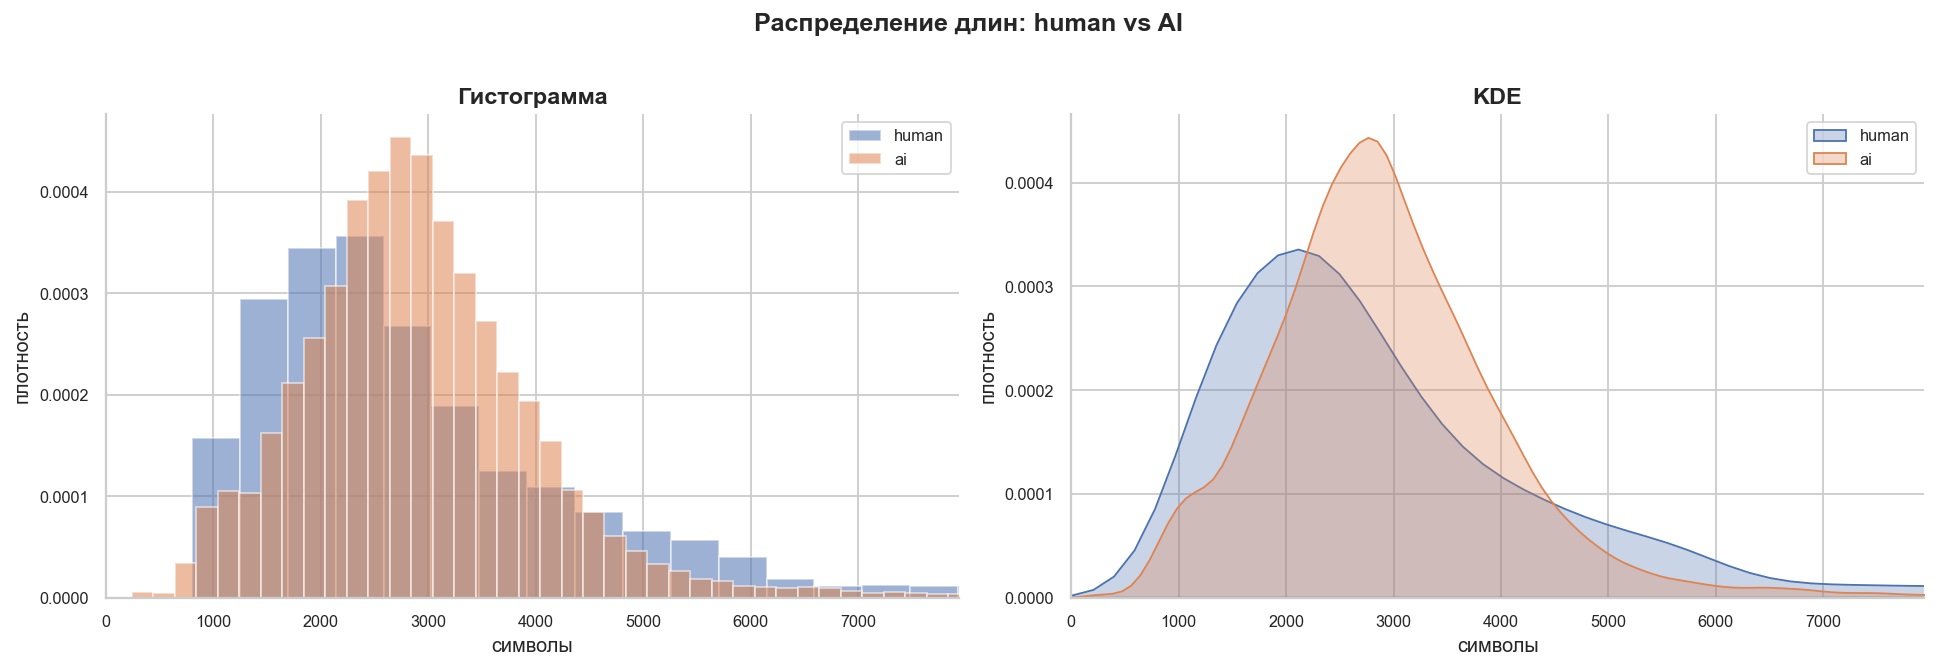

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
xlim = (0, df["text_len"].quantile(0.98))

for label, c in zip(["human", "ai"], PAL_HA):
    sub = df.loc[df["label"] == label, "text_len"]
    axes[0].hist(sub, bins=80, alpha=.55, label=label, color=c, density=True)
    sns.kdeplot(sub, ax=axes[1], label=label, color=c, fill=True, alpha=.3)

for ax, title in zip(axes, ["Гистограмма", "KDE"]):
    ax.set_xlim(xlim)
    ax.set_xlabel("символы")
    ax.set_ylabel("плотность")
    ax.set_title(title)
    ax.legend(frameon=True)

fig.suptitle("Распределение длин: human vs AI", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

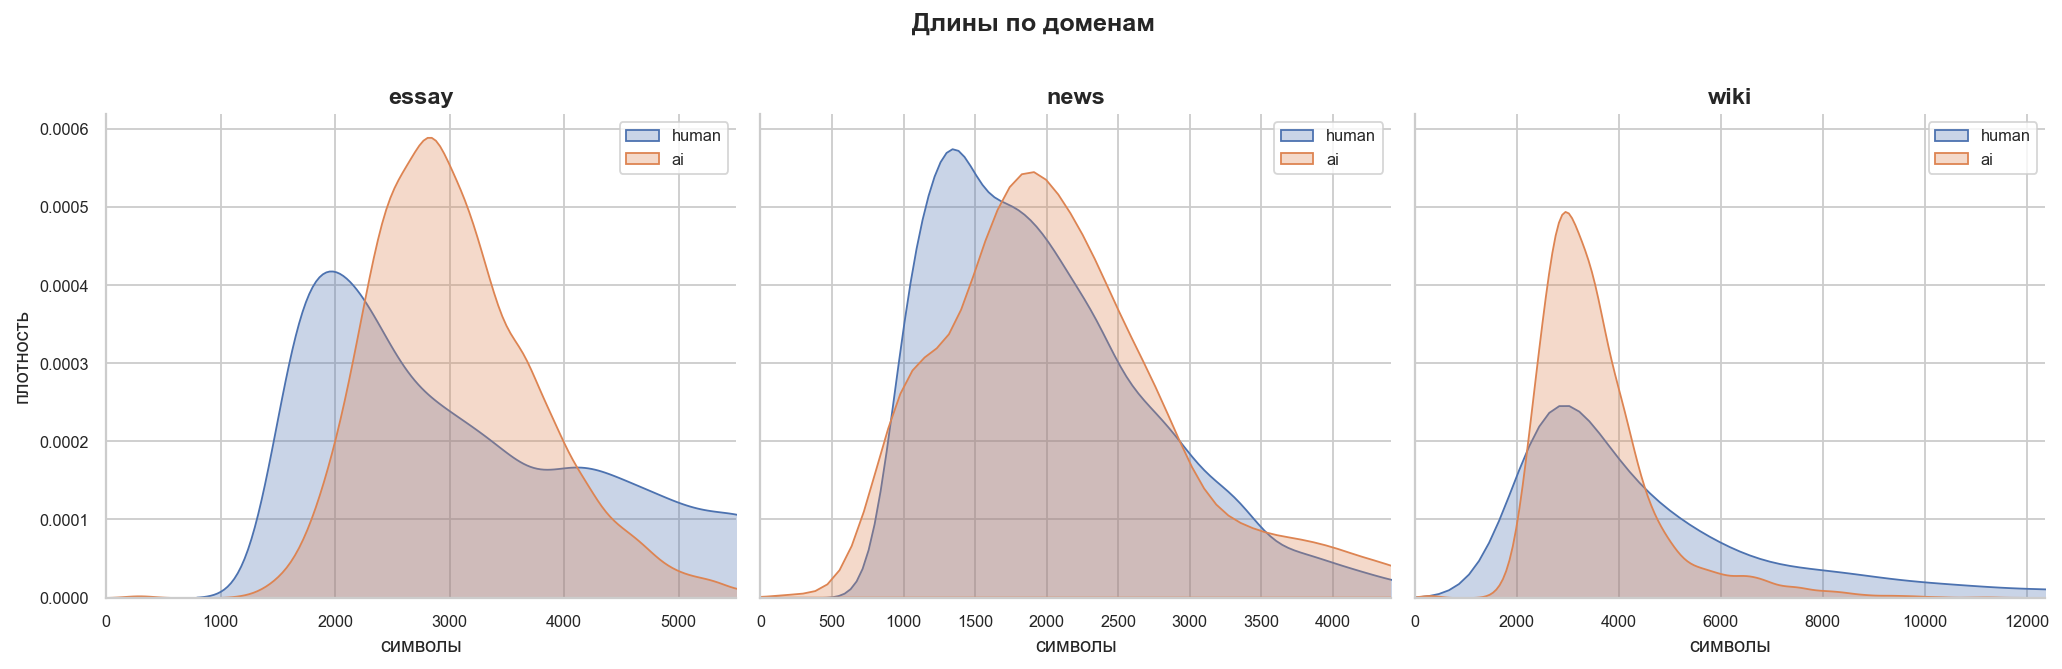

In [8]:
domains = sorted(df["domain"].unique())
fig, axes = plt.subplots(1, len(domains), figsize=(16, 5), sharey=True)

for ax, dom in zip(axes, domains):
    sub = df[df["domain"] == dom]
    for label, c in zip(["human", "ai"], PAL_HA):
        sns.kdeplot(sub.loc[sub["label"] == label, "text_len"],
                    ax=ax, label=label, color=c, fill=True, alpha=.3)
    ax.set_title(dom)
    ax.set_xlabel("символы")
    ax.set_xlim(0, sub["text_len"].quantile(.98))
    ax.legend(frameon=True)

axes[0].set_ylabel("плотность")
fig.suptitle("Длины по доменам", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

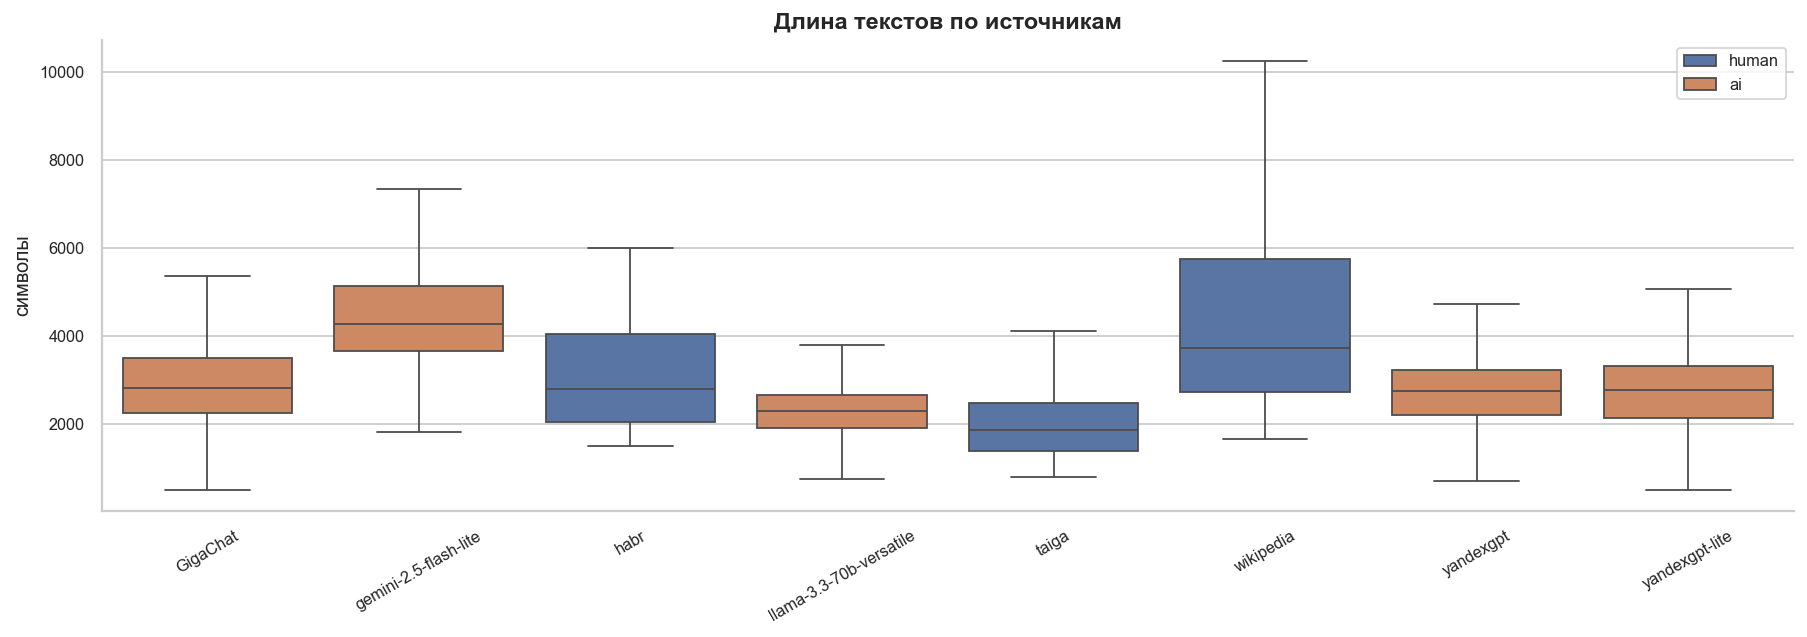

In [9]:
fig, ax = plt.subplots(figsize=(14, 5))
order = sorted(df["source_name"].unique())
sns.boxplot(data=df, x="source_name", y="text_len", hue="label",
            palette=PAL_HA, order=order, ax=ax, showfliers=False)
ax.set_title("Длина текстов по источникам")
ax.set_xlabel("")
ax.set_ylabel("символы")
ax.tick_params(axis="x", rotation=30)
ax.legend(frameon=True)
plt.tight_layout()
plt.show()

In [10]:
pcts = [.05, .25, .50, .75, .95]
pct_names = [f"P{int(p*100)}" for p in pcts]

print("Перцентили по метке:")
tbl = df.groupby("label")["text_len"].quantile(pcts).unstack().astype(int)
tbl.columns = pct_names
print(tbl.to_string())
print()
print("Перцентили по домену × метке:")
tbl2 = df.groupby(["domain", "label"])["text_len"].quantile(pcts).unstack().astype(int)
tbl2.columns = pct_names
tbl2

Перцентили по метке:
         P5   P25   P50   P75   P95
label                              
ai     1266  2223  2823  3499  4785
human  1157  1833  2537  3725  7452

Перцентили по домену × метке:


P5   P25   P50   P75    P95
domain label                               
essay  ai     2006  2526  2954  3500   4442
       human  1603  2051  2789  4058   5518
news   ai      948  1545  2012  2566   3972
       human  1026  1385  1866  2479   3584
wiki   ai     2257  2793  3298  3976   5999
       human  2204  2734  3726  5742  12646

Длина текста - потенциальный shortcut. AI-модели генерировали тексты с `target_chars`, поэтому их распределение уже (AI news P5-P95: 948-3 972). Wiki содержит тексты >10k у обоих классов.

Разница медиан небольшая (2 538 vs 2 823), но при обучении лучше нормализовать длину или контролировать через стратификацию. Интересно, насколько модель будет чувствительна к этому.

## Словарный анализ

In [ ]:
# TTR зависит от длины, для корректного сравнения нужен MATTR
df["ttr"] = df["text"].apply(ttr)

df.groupby("label").agg(
    words=("word_count", "mean"),
    sents=("sentence_count", "mean"),
    avg_wl=("avg_word_len", "mean"),
    ttr_mean=("ttr", "mean"),
).round(3).rename(columns={
    "words": "Ср. слов", "sents": "Ср. предложений",
    "avg_wl": "Ср. длина слова", "ttr_mean": "TTR",
})

,Ср. слов,Ср. предложений,Ср. длина слова,TTR
label,,,,
ai,367.990,22.726,7.938,0.685
human,440.174,33.466,7.517,0.688


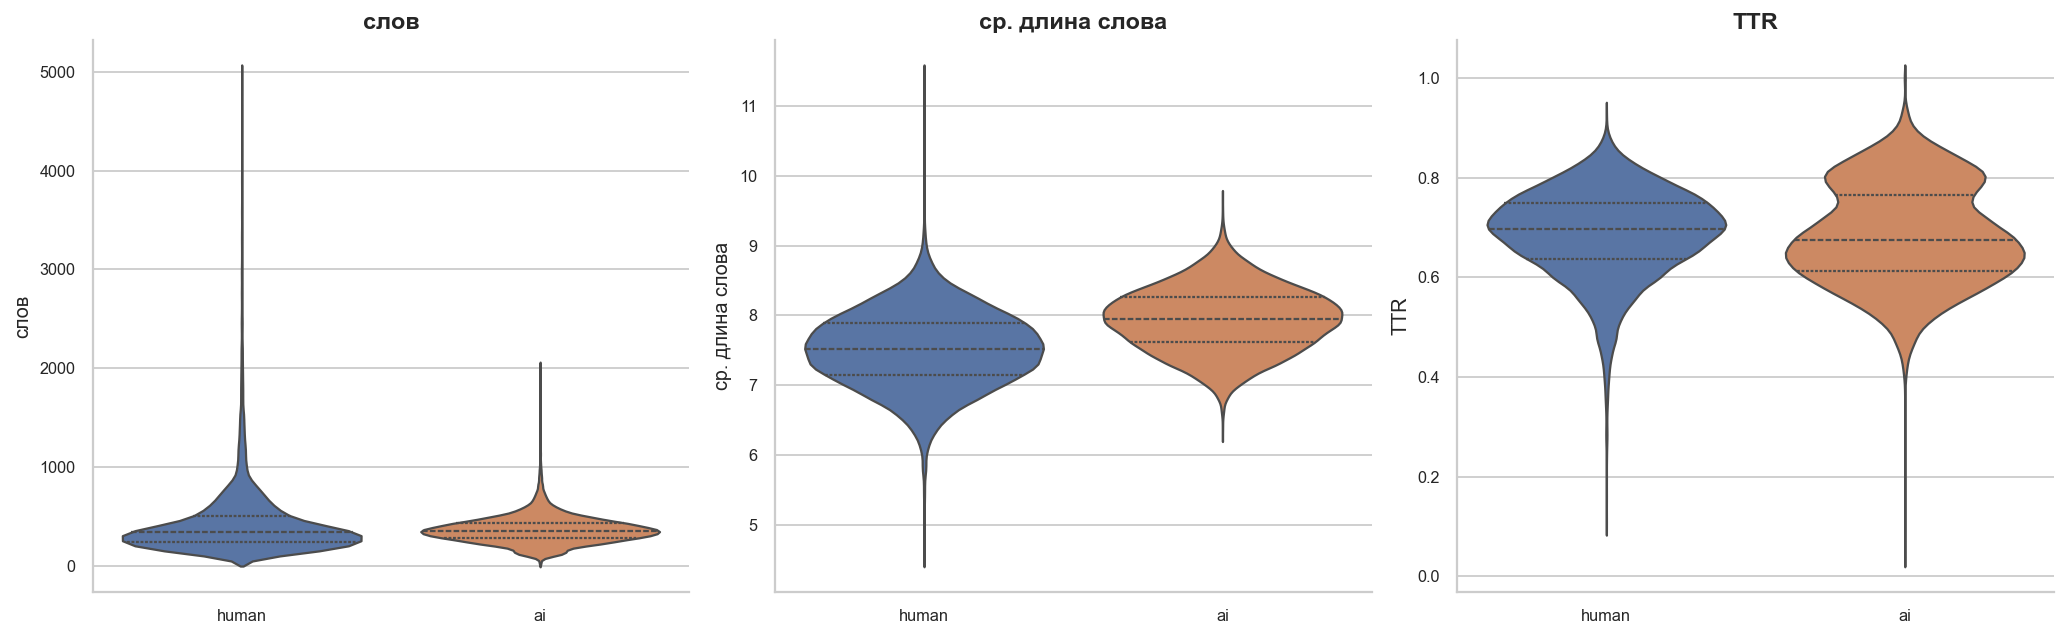

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = [("word_count", "слов"), ("avg_word_len", "ср. длина слова"), ("ttr", "TTR")]
for ax, (col, label) in zip(axes, metrics):
    sns.violinplot(data=df, x="label", y=col, hue="label",
                   palette=PAL_HA, ax=ax, inner="quartile", legend=False)
    ax.set_xlabel("")
    ax.set_ylabel(label)
    ax.set_title(label)

plt.tight_layout()
plt.show()

TTR у human и AI почти совпадает (0.688 vs 0.685) - без нормализации по длине показатель бесполезен. Средняя длина слова выше у AI: 7.94 vs 7.52, модели чаще используют длинные термины. Количество слов у human в среднем больше (440 vs 368) - это из-за длинных wiki-статей.

note: для корректного TTR нужен MATTR, обычный TTR падает с ростом длины текста.

In [13]:
df["comma_density"] = df["text"].apply(comma_density)
df["question_marks"] = df["text"].str.count(r"\?")
df["exclamation_marks"] = df["text"].str.count("!")
df["double_newlines"] = df["text"].str.count(r"\n\n")

## Статистические тесты

Проверим различия между human и AI через Mann-Whitney U и Cohen's d для размера эффекта.

In [14]:
human_sub = df[df["label"] == "human"]
ai_sub    = df[df["label"] == "ai"]

test_cols = [c for c in ["text_len", "word_count", "sentence_count",
                          "avg_word_len", "ttr", "comma_density",
                          "question_marks", "exclamation_marks", "paragraph_count"]
             if c in df.columns]

rows = []
for m in test_cols:
    h, a = human_sub[m].dropna(), ai_sub[m].dropna()
    stat, p = mannwhitneyu(h, a, alternative="two-sided")
    # pooled std для неравных выборок
    pooled = np.sqrt(((len(h)-1)*h.std()**2 + (len(a)-1)*a.std()**2) / (len(h)+len(a)-2))
    d = (a.mean() - h.mean()) / pooled if pooled > 0 else 0
    rows.append({"metric": m, "human_med": round(h.median(), 2),
                 "ai_med": round(a.median(), 2), "U": stat,
                 "p": p, "d": round(d, 3)})

mw = pd.DataFrame(rows)
mw["sig"] = mw["p"] < 0.001
mw["effect"] = mw["d"].abs().apply(
    lambda x: "large" if x > .8 else "medium" if x > .5 else "small")
mw

,metric,human_med,ai_med,U,p,d,sig,effect
0,text_len,2537.50,2823.00,169289802.0,3.033329e-39,-0.169,True,small
1,word_count,341.00,357.00,181952871.0,1.229052e-01,-0.277,False,small
2,sentence_count,21.00,21.00,193586534.5,1.033419e-19,-0.369,True,small
3,avg_word_len,7.52,7.95,101793431.5,0.000000e+00,0.846,True,large
4,ttr,0.70,0.68,192509218.0,5.630889e-16,-0.025,True,small
5,comma_density,1.14,1.28,149320685.0,1.209107e-215,0.214,True,small
6,question_marks,0.00,0.00,137992332.5,0.000000e+00,0.449,True,small
7,exclamation_marks,0.00,0.00,188942120.0,1.086290e-41,-0.092,True,small
8,paragraph_count,1.00,9.00,57331912.0,0.000000e+00,0.805,True,large


Все метрики значимы (p < 0.001), кроме `word_count` (p = 0.12).

По размеру эффекта: `avg_word_len` (d = 0.83) - самое выраженное стилистическое различие. `paragraph_count` (d = 0.79) - сильный, но это shortcut из-за форматирования. Остальные метрики дают слабый эффект: `text_len` (d = -0.16), `sentence_count` (d = -0.33), `ttr` (d = -0.03).

Получается, `avg_word_len` - самый устойчивый сигнал среди всех метрик, а `paragraph_count` нужно аккуратно использовать, потому что это артефакт форматирования.


После поправки Bonferroni (alpha/9 = 0.0056) все результаты остаются значимыми.

In [15]:
style = df.groupby("label").agg(
    commas=("comma_density", "mean"),
    questions=("question_marks", "mean"),
    excl=("exclamation_marks", "mean"),
    paras=("paragraph_count", "mean"),
).round(2)
style.columns = ["Запятых/предл.", "? (ср.)", "! (ср.)", "Абзацев (ср.)"]
style

,Запятых/предл.,? (ср.),! (ср.),Абзацев (ср.)
label,,,,
ai,1.34,0.88,0.05,11.17
human,1.21,0.20,0.15,4.67


In [16]:
print("Двойные переносы (\\n\\n):")
print(df.groupby("label")["double_newlines"].describe()[["mean", "50%", "75%", "max"]].round(1))

Двойные переносы (\n\n):
       mean  50%   75%   max
label                       
ai      8.7  7.0  12.0  46.0
human   0.0  0.0   0.0   6.0


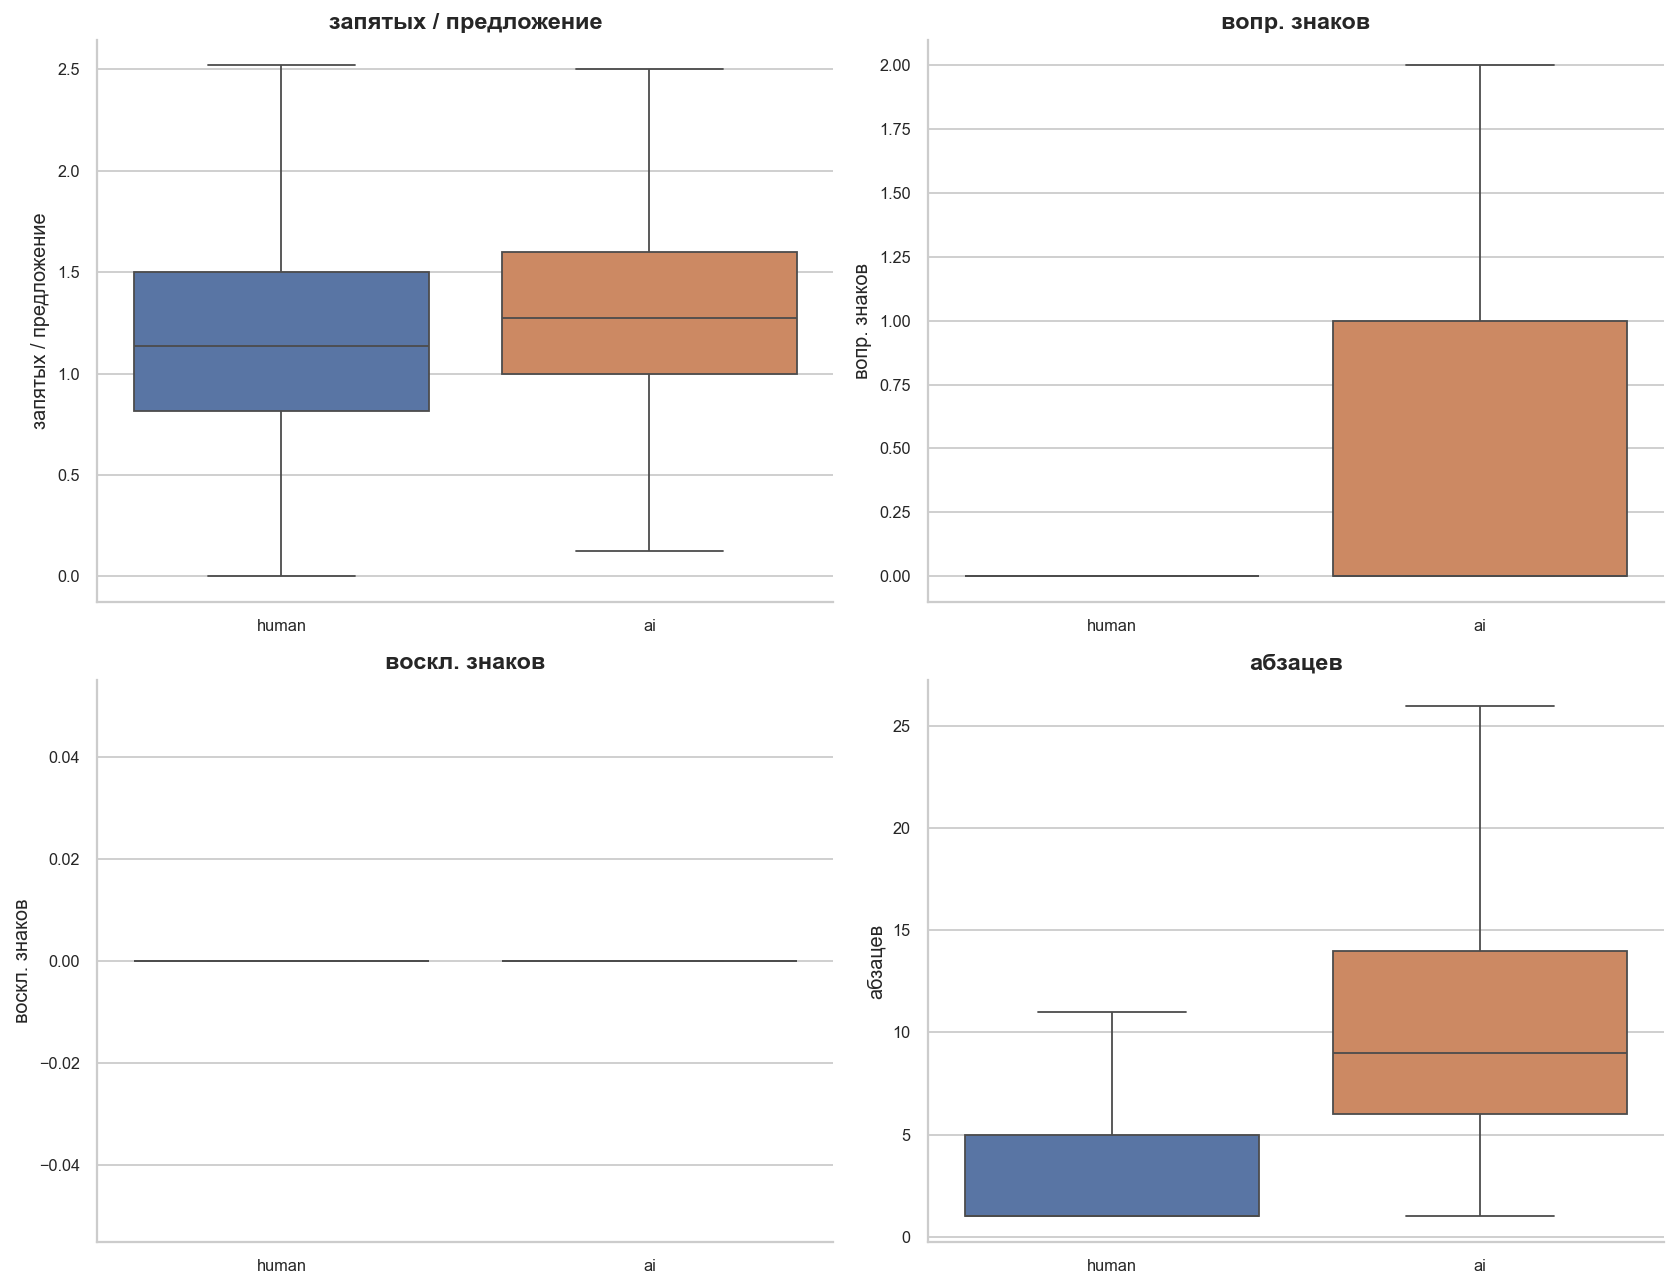

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

plots = [
    ("comma_density", "запятых / предложение"),
    ("question_marks", "вопр. знаков"),
    ("exclamation_marks", "воскл. знаков"),
    ("paragraph_count", "абзацев"),
]
for ax, (col, label) in zip(axes.flat, plots):
    sns.boxplot(data=df, x="label", y=col, hue="label",
                palette=PAL_HA, ax=ax, showfliers=False, legend=False)
    ax.set_ylabel(label)
    ax.set_xlabel("")
    ax.set_title(label)

plt.tight_layout()
plt.show()

AI-тексты содержат в 4 раза больше вопросительных знаков (0.88 vs 0.20) - LLM любят риторические вопросы. Восклицательные знаки, наоборот, чаще у human (0.15 vs 0.05). Плотность запятых примерно одинаковая.

Двойные переносы `\n\n` - ключевой артефакт: median 7 у AI vs 0 у human. Human-тексты прошли предобработку и потеряли форматирование, а AI сохраняют markdown-структуру.

### Markdown-разметка

In [18]:
_md_re = re.compile(r"^#{1,3}\s|^\*\*|^- |^\d+\. |```", re.MULTILINE)

rows = []
for src in df["source_name"].unique():
    sub = df[df["source_name"] == src]
    n_md = sub["text"].apply(lambda t: bool(_md_re.search(t))).sum()
    rows.append({"source": src, "label": sub["label"].iloc[0],
                 "markdown": n_md, "всего": len(sub),
                 "%": round(n_md / len(sub) * 100, 1)})

pd.DataFrame(rows).sort_values(["label", "%"], ascending=[True, False])

,source,label,markdown,всего,%
3,gemini-2.5-flash-lite,ai,2588,2862,90.4
6,yandexgpt-lite,ai,7784,8842,88.0
7,yandexgpt,ai,2333,2948,79.1
4,GigaChat,ai,4098,5999,68.3
5,llama-3.3-70b-versatile,ai,133,2999,4.4
0,habr,human,31,4000,0.8
1,taiga,human,0,6749,0.0
2,wikipedia,human,0,4781,0.0


Markdown - главный shortcut. Gemini (90.4%), yandexgpt-lite (88.0%), yandexgpt (79.1%), GigaChat (68.3%) генерируют с markdown. Llama почти без него (4.4%). У human: habr 0.8%, taiga 0%, wiki 0%.

Перед обучением обязательна очистка `strip_markdown`, иначе модель выучит форматирование вместо стилистики. note: это самый опасный shortcut в датасете.

### Лексический анализ

Top-30 слов для human и AI, затем log-odds ratio для поиска LLM-маркеров.

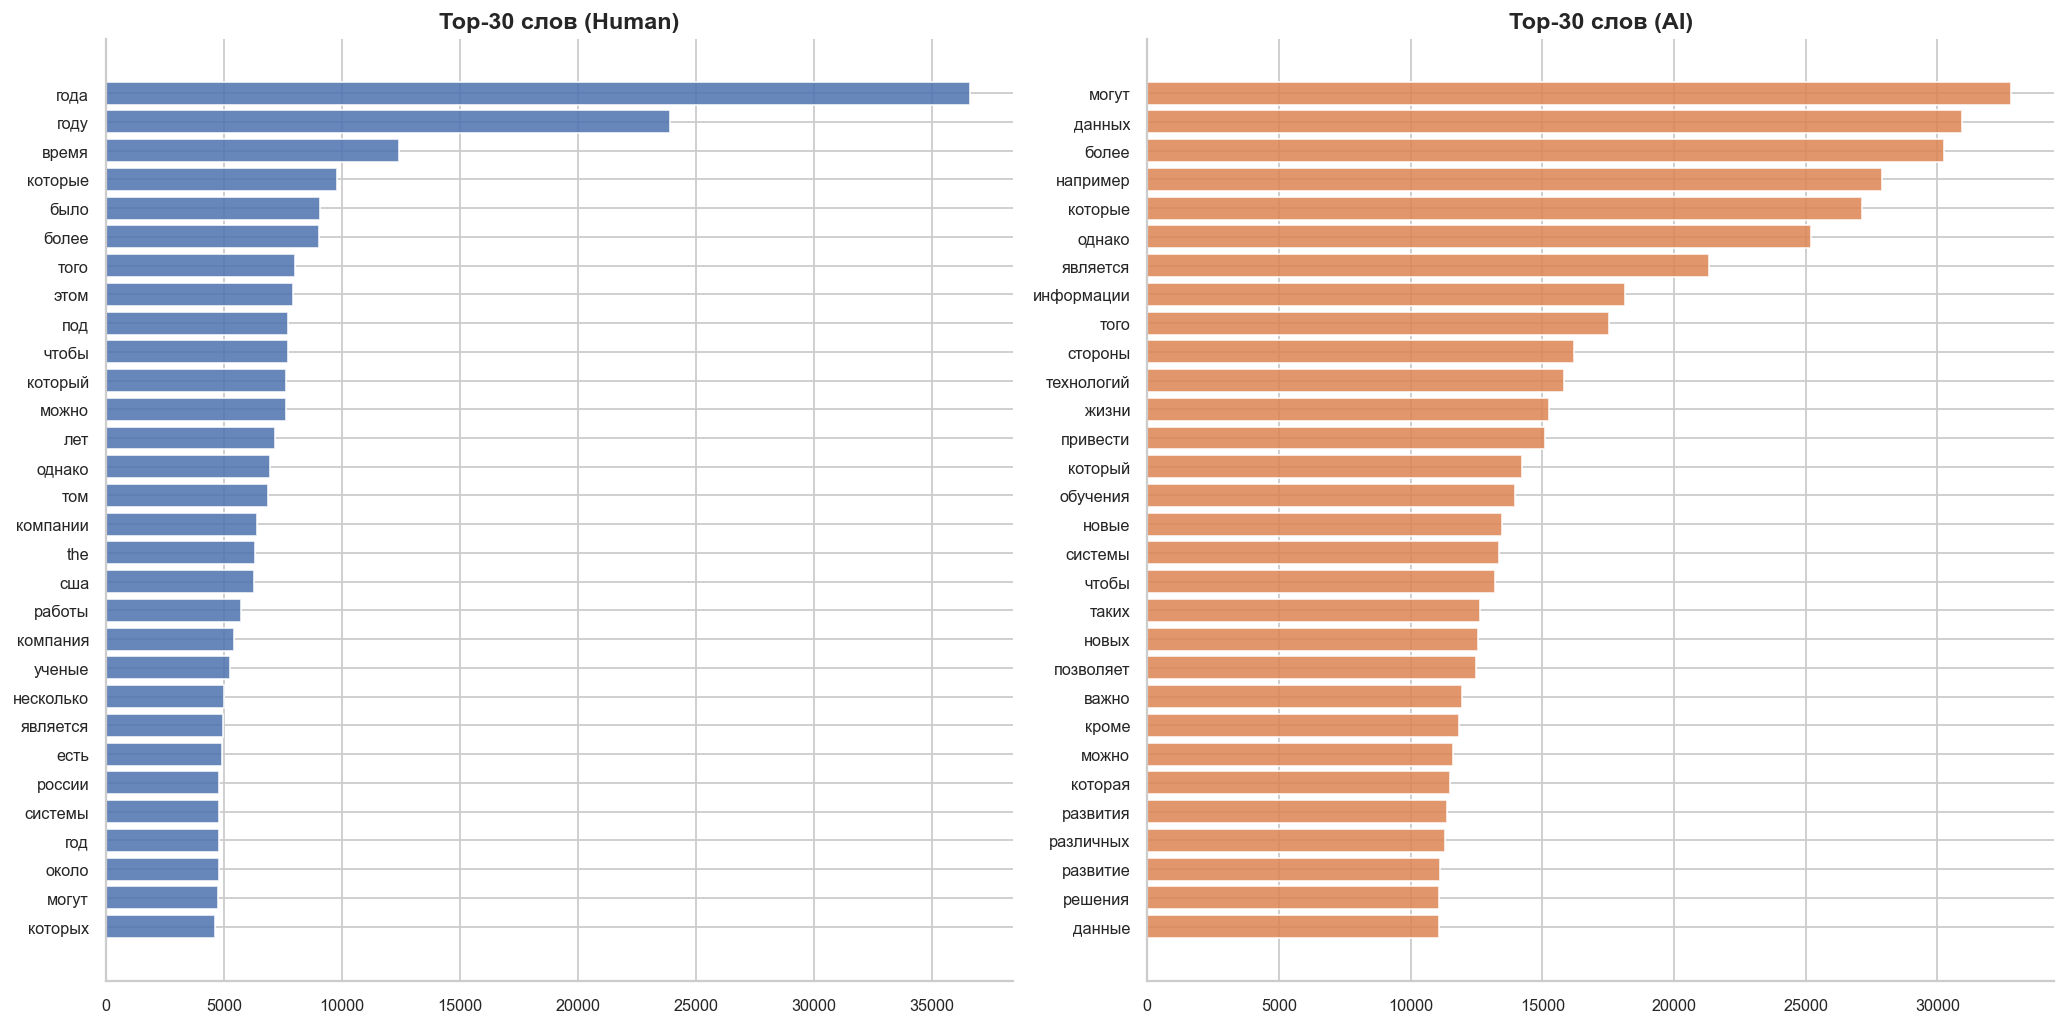

In [19]:
RU_STOP = set(
    "и в на с по для не что как это а но или к из от до за при о об у же бы ли ни "
    "то так уже ещё его её их мы вы они он она оно я ты мне мой мою свой свою "
    "этот эта эти этого этой этих весь вся всё все всех всей всего нет да был была были "
    "быть будет может один одна одно одни другой другая другие каждый между после перед "
    "если только когда где чем кто чего кого чему кому чей чья чьё чьи также ещё".split()
)

def count_words(texts):
    wc = Counter()
    for t in texts:
        tokens = re.findall(r"[а-яёa-z]{3,}", t.lower())
        wc.update(tok for tok in tokens if tok not in RU_STOP)
    return wc

human_wc = count_words(df.loc[df["label"] == "human", "text"])
ai_wc    = count_words(df.loc[df["label"] == "ai", "text"])

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
for ax, (wc, name, c) in zip(axes, [(human_wc, "Human", C_HUMAN), (ai_wc, "AI", C_AI)]):
    top = wc.most_common(30)
    ax.barh([w for w, _ in top], [n for _, n in top], color=c, alpha=.85)
    ax.set_title(f"Top-30 слов ({name})")
    ax.invert_yaxis()
plt.tight_layout()
plt.show()

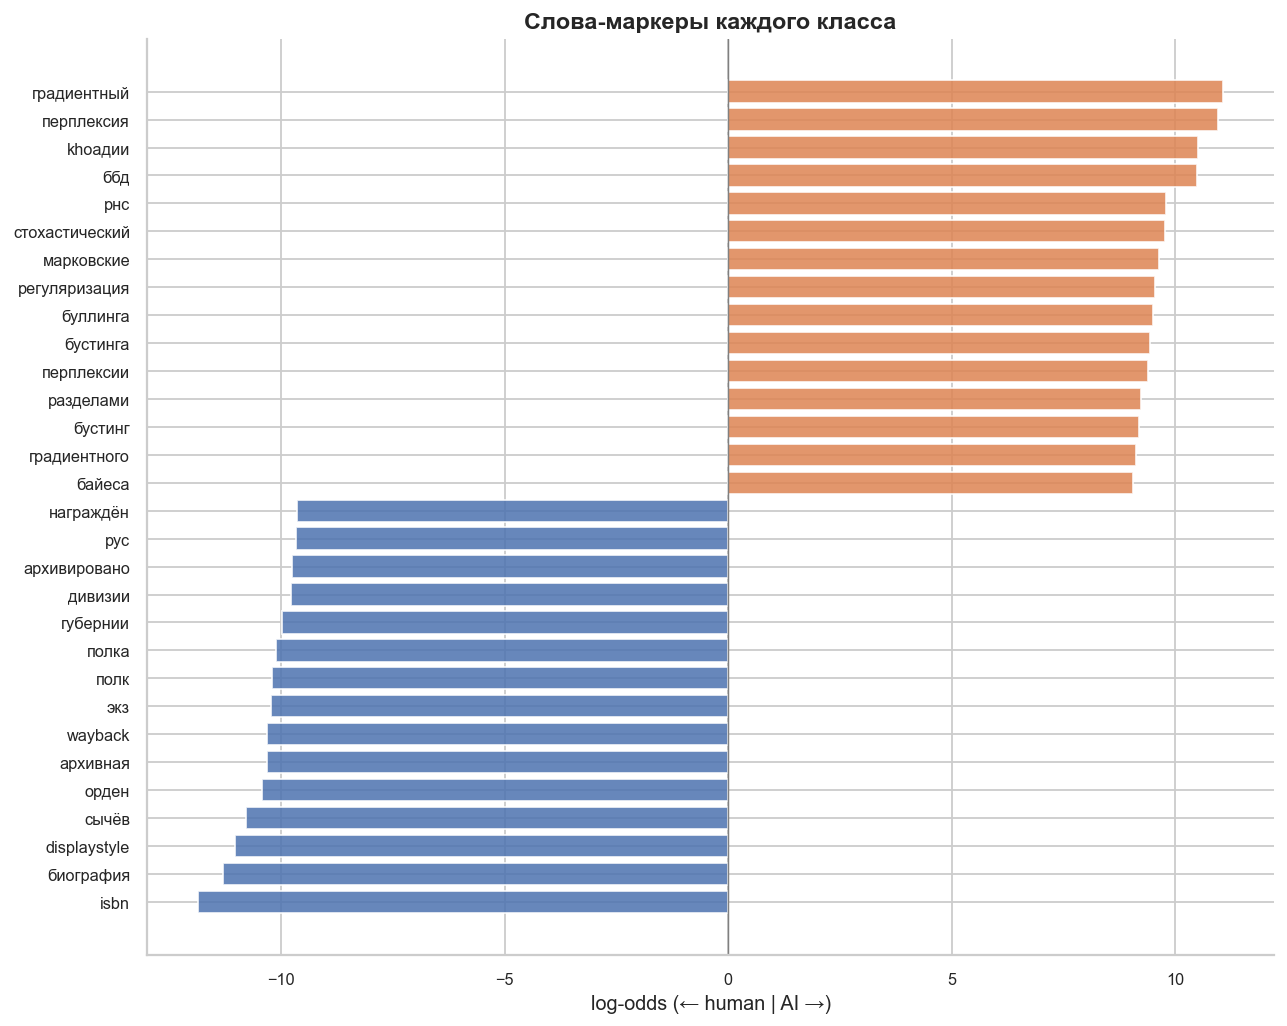

In [20]:
# log-odds ratio
# можно попробовать PMI вместо log-odds
h_total, a_total = sum(human_wc.values()), sum(ai_wc.values())
vocab = set(w for w, _ in human_wc.most_common(2000)) | set(w for w, _ in ai_wc.most_common(2000))

log_odds = {}
for w in vocab:
    hf = (human_wc[w] + 1) / (h_total + len(vocab))
    af = (ai_wc[w] + 1) / (a_total + len(vocab))
    log_odds[w] = np.log2(af / hf)

lo = sorted(log_odds.items(), key=lambda x: x[1])
top_h, top_a = lo[:15], lo[-15:]

fig, ax = plt.subplots(figsize=(10, 8))
words  = [w for w, _ in top_h + top_a]
scores = [s for _, s in top_h + top_a]
colors = [C_HUMAN] * 15 + [C_AI] * 15
ax.barh(words, scores, color=colors, alpha=.85)
ax.set_xlabel("log-odds (← human | AI →)")
ax.set_title("Слова-маркеры каждого класса")
ax.axvline(0, color="grey", lw=.8)
plt.tight_layout()
plt.show()

Log-odds ratio показывает LLM-маркеры: AI-тексты перенасыщены словами `является`, `контекст`, `аспект`, `определённый`. Human-тексты содержат конкретную лексику из предметных областей - научные термины, имена, аббревиатуры. Эти различия можно использовать для feature engineering.

### Шаблонные фразы AI

Проверим, насколько часто LLM используют шаблонные окончания и начала.

In [21]:
FORMULAIC = re.compile(
    r"в заключение|таким образом|подводя итог|в целом,?\s|резюмируя|итак,",
    re.IGNORECASE,
)
df["ends_formulaic"] = df["text"].apply(
    lambda t: bool(FORMULAIC.search(t[-300:])) if len(t) > 100 else False
)

print("Шаблонные окончания (доля):")
print(df.groupby("label")["ends_formulaic"].mean().round(3).to_string())
print()
print("По доменам:")
print(df.groupby(["domain", "label"])["ends_formulaic"].mean().round(3).unstack().to_string())
print()

for lbl_name, lbl_val in [("Human", "human"), ("AI", "ai")]:
    starts = (df.loc[df["label"] == lbl_val, "text"]
              .apply(lambda t: " ".join(t.split()[:5]))
              .value_counts().head(10))
    print(f"Top-10 начал ({lbl_name}):")
    print(starts.to_string())
    print()

Шаблонные окончания (доля):
label
ai       0.172
human    0.015

По доменам:
label      ai  human
domain              
essay   0.074  0.016
news    0.138  0.023
wiki    0.303  0.004

Top-10 начал (Human):
text
Американские ученые пришли к выводу,                           18
Агентство перспективных оборонных разработок (DARPA)           15
Федеральное управление гражданской авиации США                 13
Международная группа астрономов под руководством               13
Исследователи из Калифорнийского университета в                13
Международная группа ученых обнаружила, что                    13
Группа ученых во главе с                                        9
Самолет на солнечных батареях Solar                             9
В этой статье представлен список                                8
Исследователи из Массачусетского технологического института     7

Top-10 начал (AI):
text
**Анонимность в интернете: свобода или               81
**Роль университетского образования в XXI        

17.2% AI-текстов содержат шаблонные окончания vs 1.5% human. В wiki-домене разрыв ещё больше: 30.3% AI vs 0.4% human. Это устойчивый стилистический сигнал, который не зависит от markdown - можно использовать как признак.

Интересно, сохранится ли этот паттерн после adversarial-атак, когда AI будет намеренно избегать шаблонов.

## Доменный анализ

In [22]:
df.groupby(["domain", "label"]).agg(
    n=("text", "size"),
    avg_len=("text_len", "mean"),
    words=("word_count", "mean"),
    ttr_m=("ttr", "mean"),
    commas=("comma_density", "mean"),
    paras=("paragraph_count", "mean"),
).round(2).rename(columns={
    "n": "Кол-во", "avg_len": "Ср. длина", "words": "Ср. слов",
    "ttr_m": "TTR", "commas": "Запятых/предл.", "paras": "Абзацев",
})

Кол-во  Ср. длина  Ср. слов   TTR  Запятых/предл.  Абзацев
domain label                                                            
essay  ai       7916    3056.19    391.21  0.67            1.44     9.11
       human    4000    3109.44    425.04  0.67            1.28    15.25
news   ai       7777    2147.43    272.44  0.74            1.24     7.63
       human    6749    2029.32    260.15  0.75            1.29     1.00
wiki   ai       7957    3555.46    438.28  0.65            1.33    16.68
       human    4781    5082.64    706.97  0.62            1.03     1.00

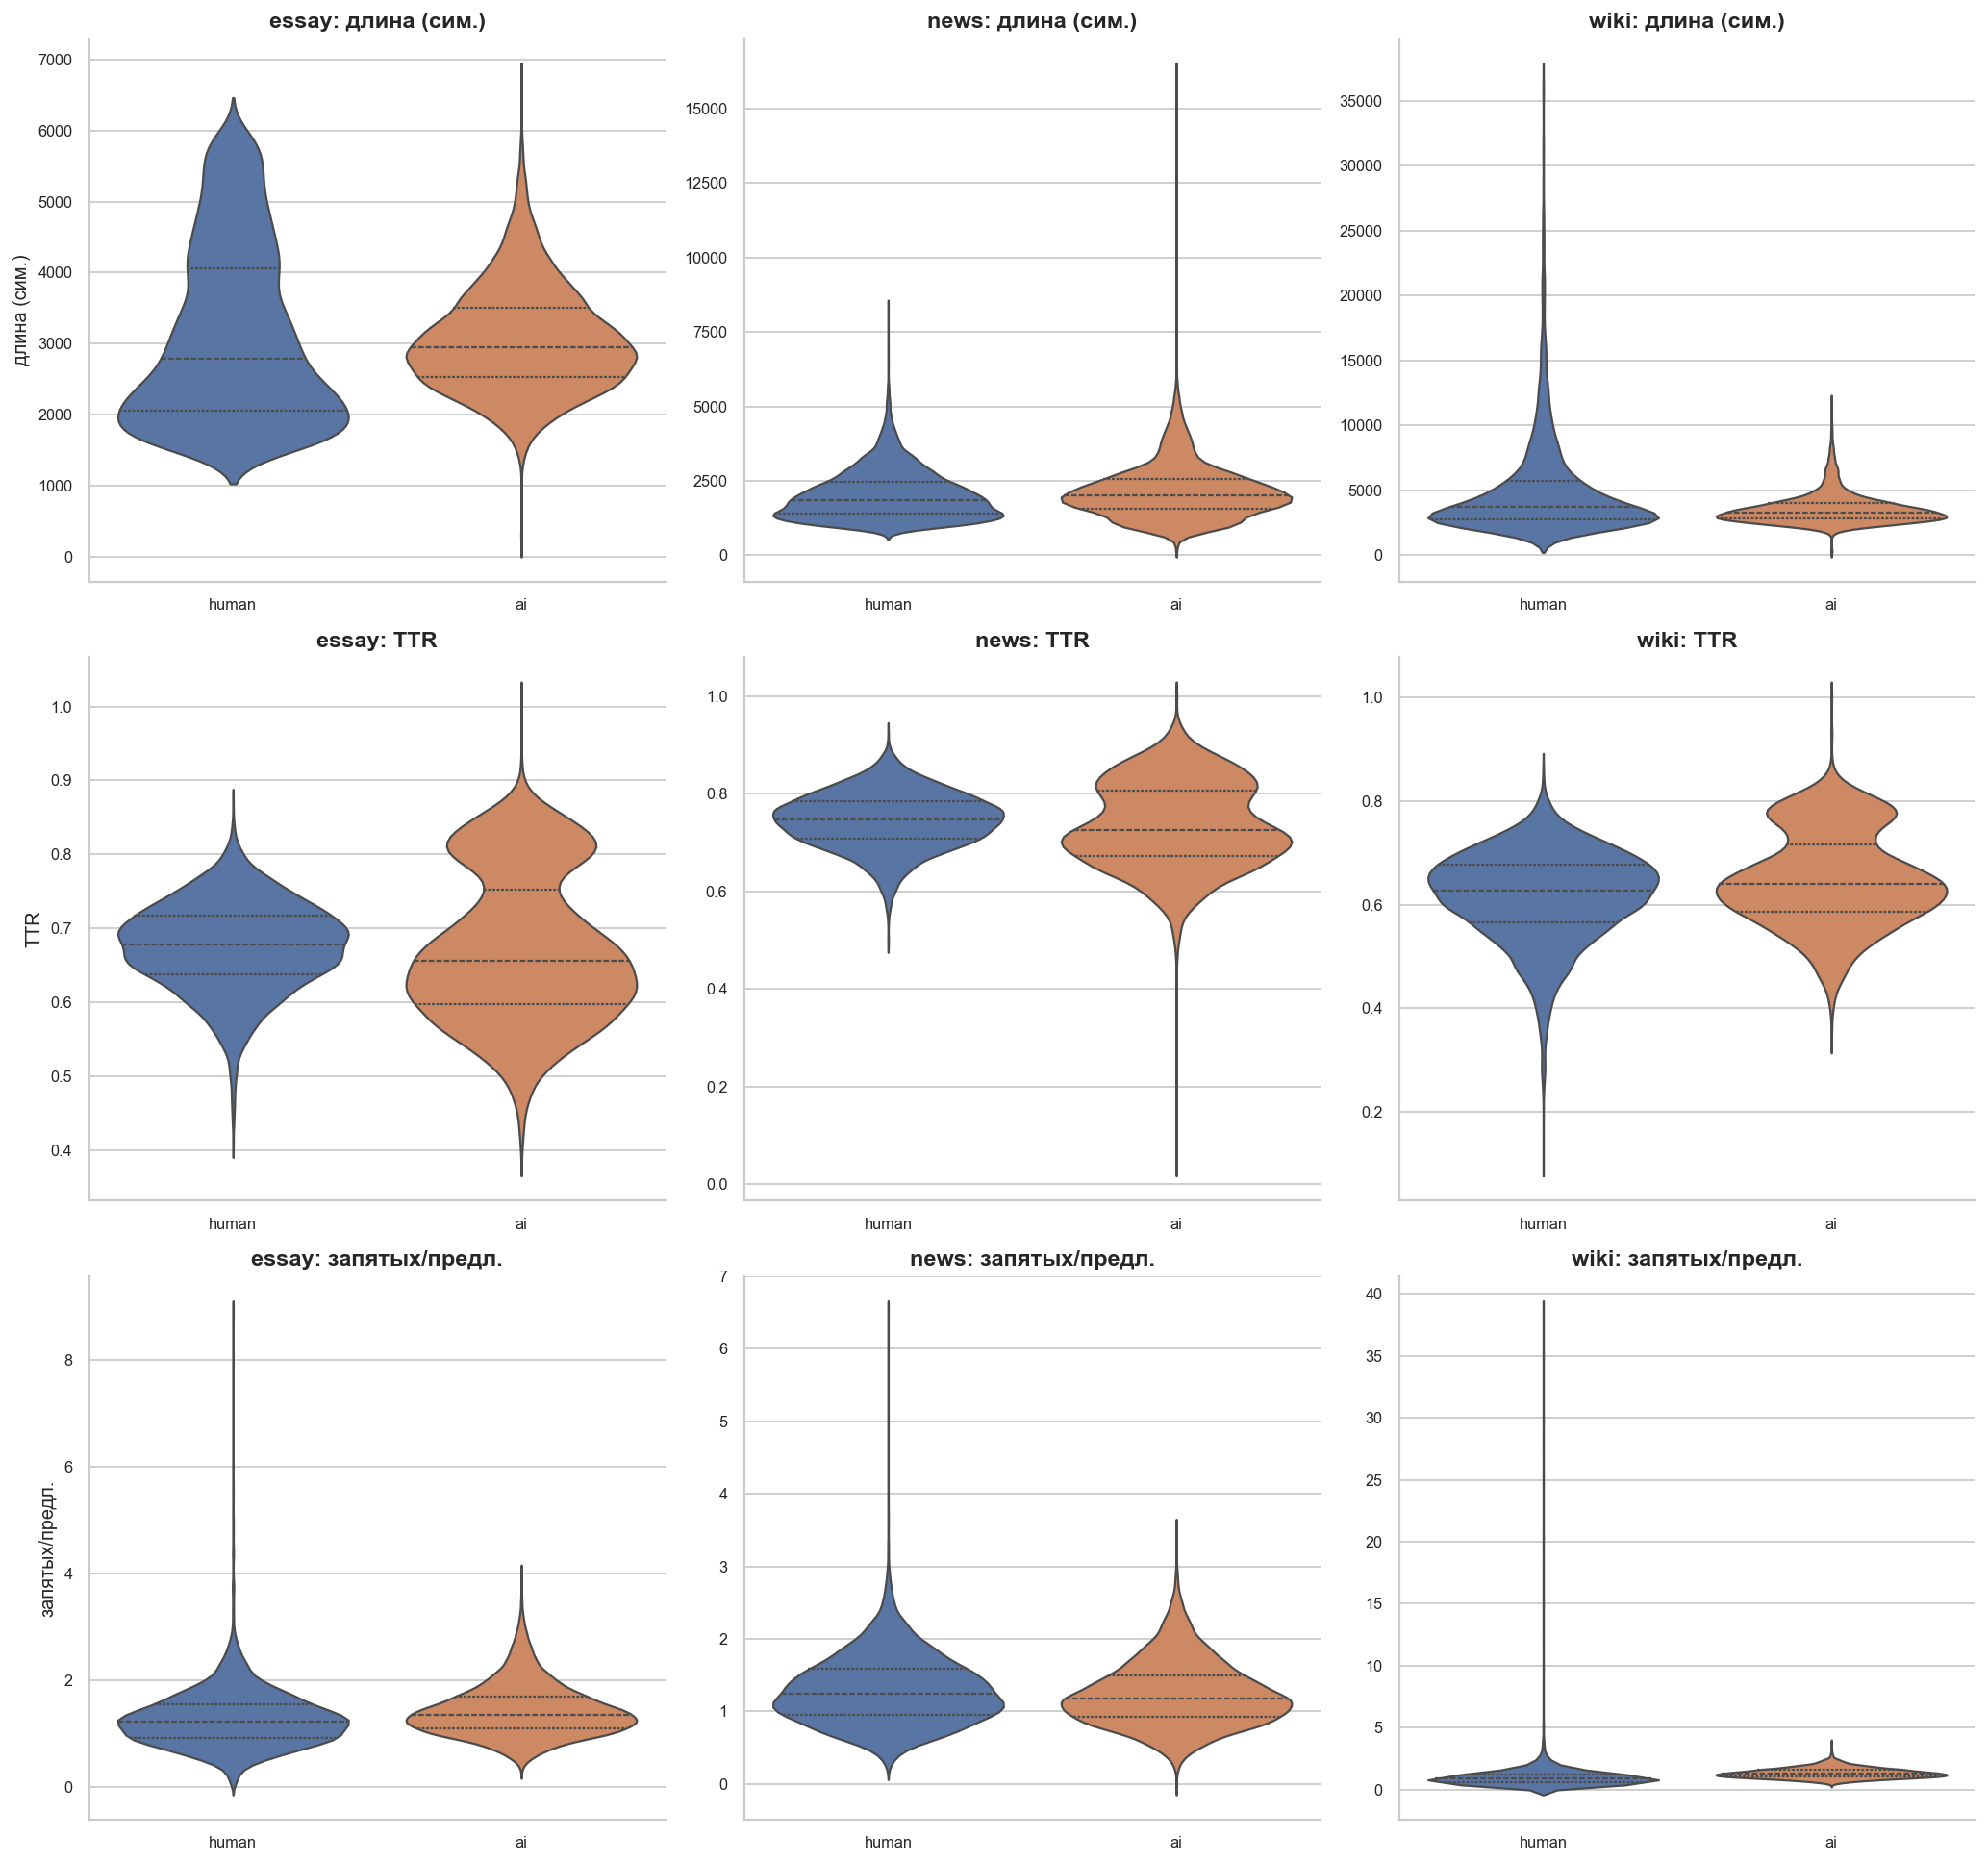

In [23]:
feats = [("text_len", "длина (сим.)"), ("ttr", "TTR"), ("comma_density", "запятых/предл.")]

fig, axes = plt.subplots(len(feats), len(domains), figsize=(16, 5 * len(feats)))
for row, (feat, feat_lbl) in enumerate(feats):
    for col, dom in enumerate(domains):
        ax = axes[row, col]
        sub = df[df["domain"] == dom]
        sns.violinplot(data=sub, x="label", y=feat, hue="label",
                       palette=PAL_HA, ax=ax, inner="quartile", legend=False)
        ax.set_title(f"{dom}: {feat_lbl}")
        ax.set_xlabel("")
        ax.set_ylabel(feat_lbl if col == 0 else "")

plt.tight_layout()
plt.show()

Домены заметно отличаются. News (taiga) - короткие тексты (median ~2k), высокий TTR. Essay (habr) - средняя длина, у human больше абзацев (15 vs 9). Wiki - самые длинные тексты обоих классов, максимальная разница в markdown.

note: при обучении надо учитывать домен, иначе модель рискует выучить доменные различия вместо стилистических.

## Сравнение моделей-генераторов

In [24]:
df_ai = df[df["label"] == "ai"].copy()
model_order = sorted(df_ai["source_name"].unique())

df_ai.groupby("source_name").agg(
    n=("text", "size"),
    avg_len=("text_len", "mean"),
    med_len=("text_len", "median"),
    ttr_m=("ttr", "mean"),
    commas=("comma_density", "mean"),
    wl=("avg_word_len", "mean"),
).round(2).rename(columns={
    "n": "Кол-во", "avg_len": "Ср. длина", "med_len": "Медиана",
    "ttr_m": "TTR", "commas": "Запятых/предл.", "wl": "Ср. длина слова",
})

,Кол-во,Ср. длина,Медиана,TTR,Запятых/предл.,Ср. длина слова
source_name,,,,,,
GigaChat,5999,2861.70,2816.0,0.81,1.17,8.21
gemini-2.5-flash-lite,2862,4569.41,4264.5,0.68,1.87,7.91
llama-3.3-70b-versatile,2999,2278.59,2307.0,0.65,1.74,7.78
yandexgpt,2948,2717.86,2756.5,0.64,1.26,7.85
yandexgpt-lite,8842,2724.89,2785.0,0.63,1.18,7.85


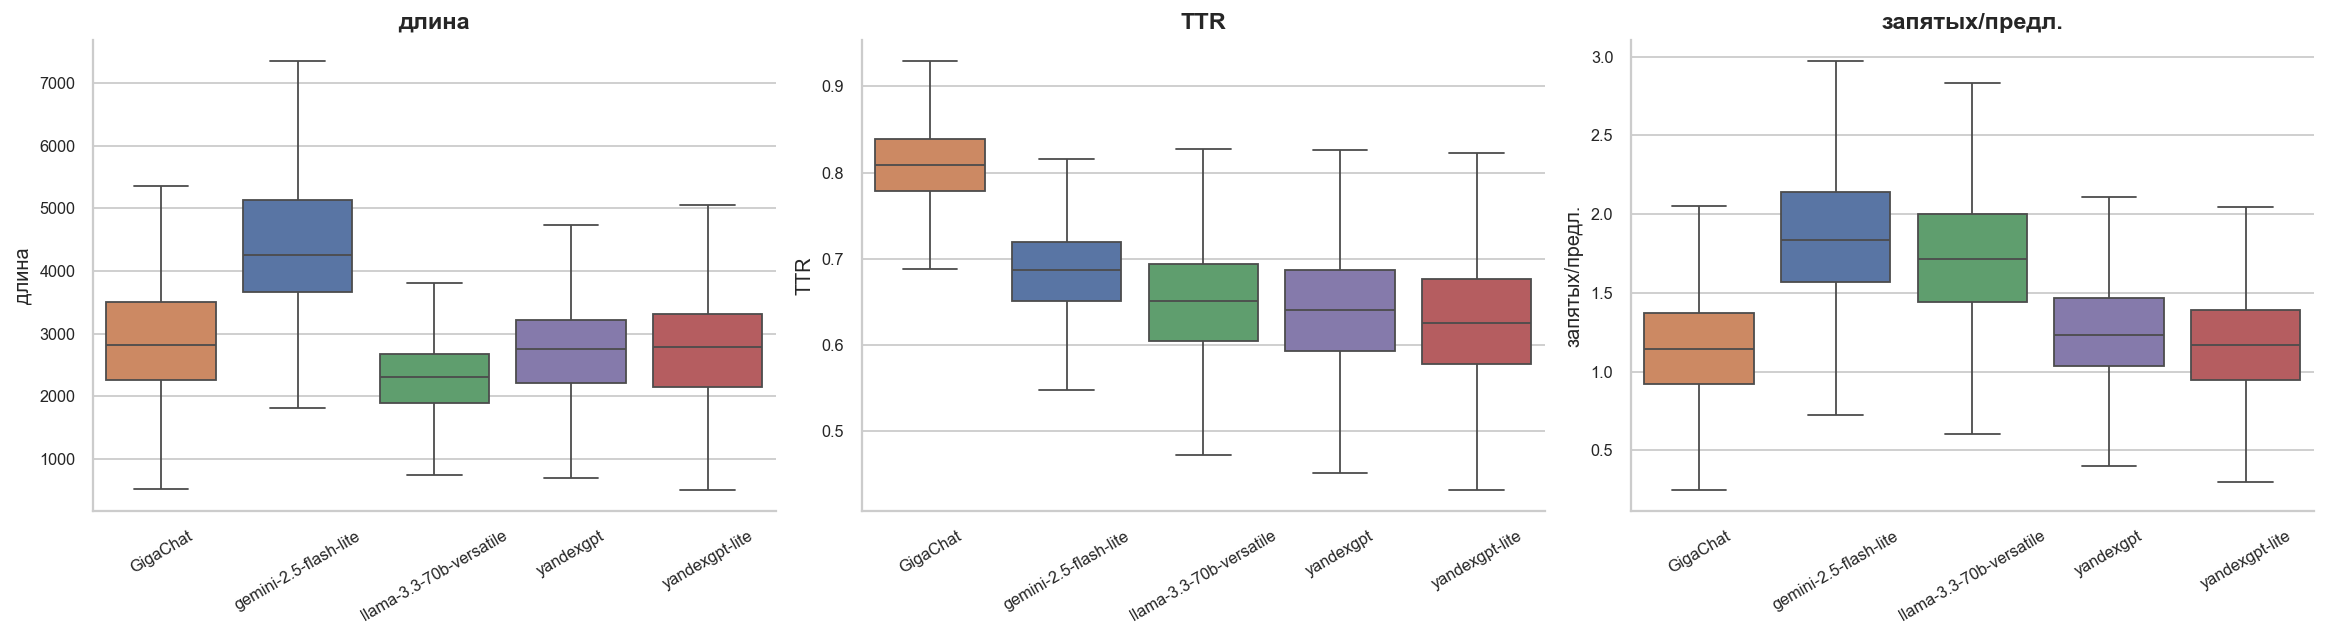

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (col, lbl) in zip(axes, [("text_len", "длина"), ("ttr", "TTR"), ("comma_density", "запятых/предл.")]):
    sns.boxplot(data=df_ai, x="source_name", y=col, hue="source_name",
                order=model_order, ax=ax, showfliers=False, legend=False)
    ax.set_title(lbl)
    ax.set_xlabel("")
    ax.set_ylabel(lbl)
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

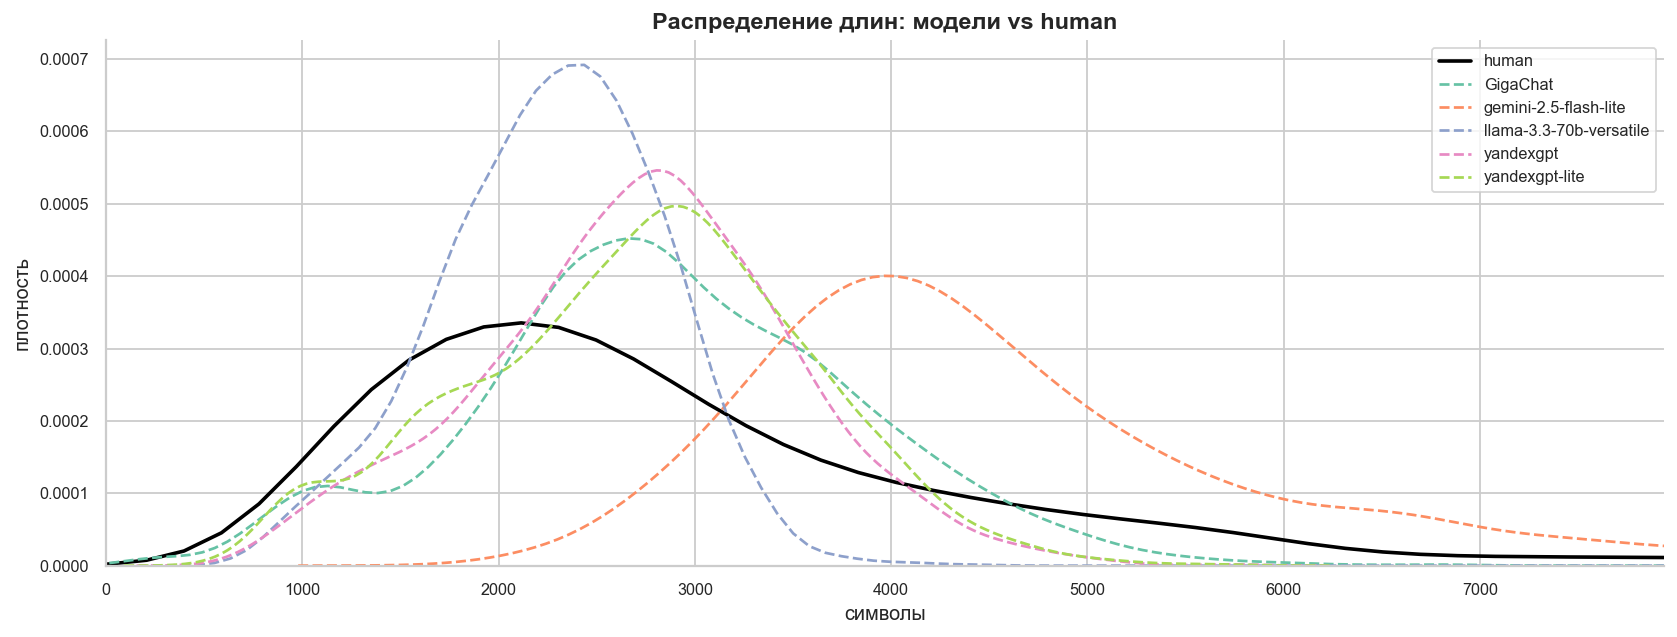

In [26]:
# KDE длин: модели vs human
fig, ax = plt.subplots(figsize=(13, 5))
sns.kdeplot(df.loc[df["label"] == "human", "text_len"],
            ax=ax, label="human", color="black", lw=2)

for model, c in zip(model_order, sns.color_palette("Set2", len(model_order))):
    sns.kdeplot(df_ai.loc[df_ai["source_name"] == model, "text_len"],
                ax=ax, label=model, color=c, ls="--")

ax.set_xlim(0, df["text_len"].quantile(.98))
ax.set_xlabel("символы")
ax.set_ylabel("плотность")
ax.set_title("Распределение длин: модели vs human")
ax.legend(fontsize=9, frameon=True)
plt.tight_layout()
plt.show()

Модели заметно различаются стилистически. GigaChat - самый высокий TTR (0.81), средняя длина слова 8.21. Gemini генерирует длинные тексты (median 4 265 сим.) и активно вставляет markdown. Llama - компактный стиль, почти без markdown (4.4%), низкий TTR (0.65). YandexGPT-lite доминирует по объёму: 8 842 текста, 37% всех AI.

Для holdout-оценки разумно вынести одну модель в unseen-сплит - можно попробовать yandexgpt.

### TF-IDF анализ

Дискриминативные n-граммы между классами дают более взвешенную картину, чем частоты слов.

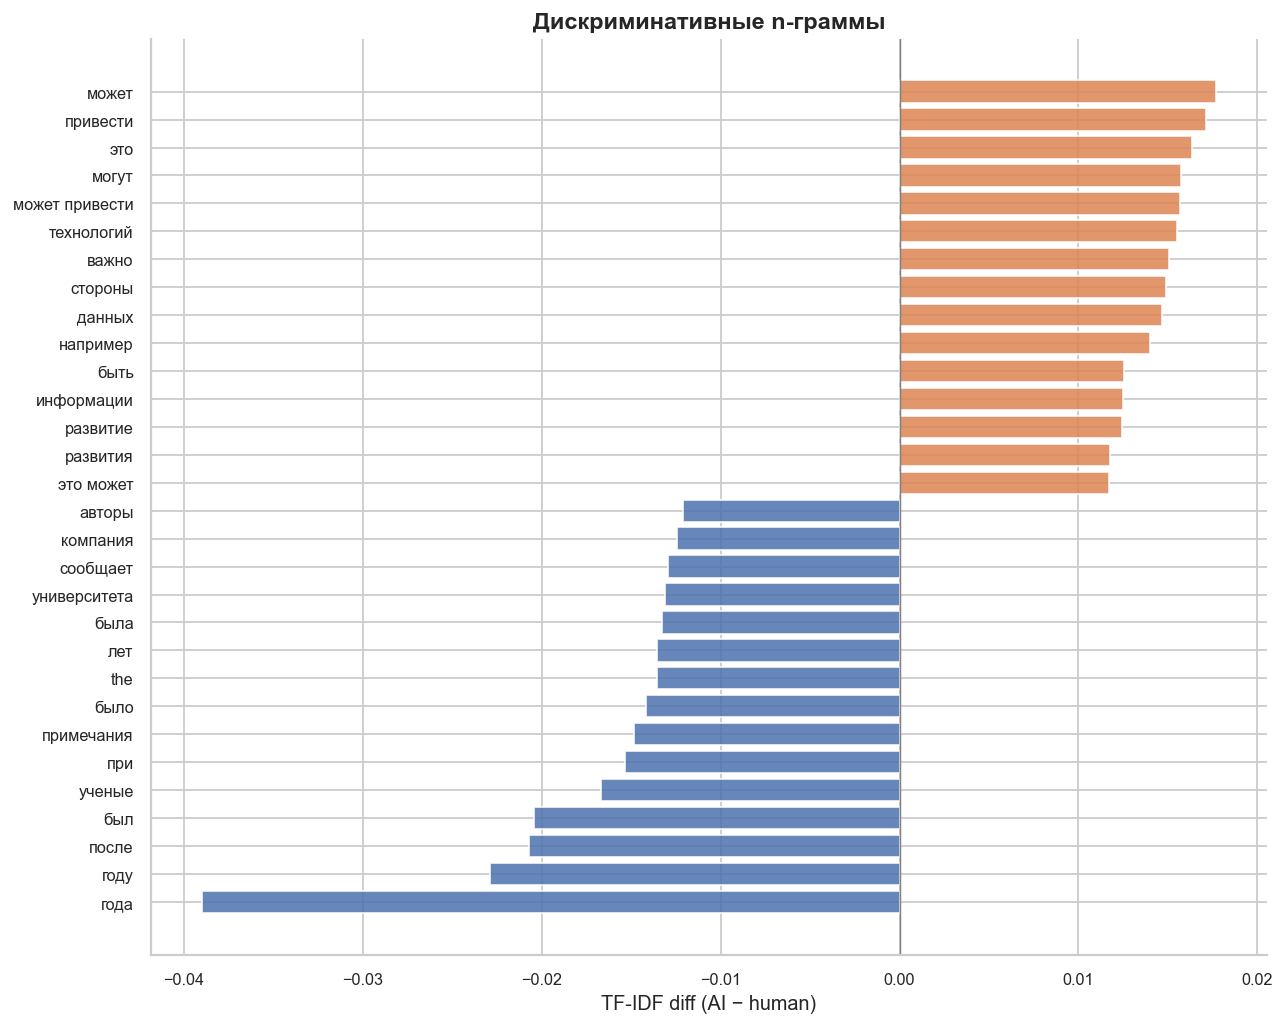

In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer

vec = TfidfVectorizer(max_features=5000, ngram_range=(1, 2),
                      token_pattern=r"[а-яёa-z]{3,}", sublinear_tf=True)
X = vec.fit_transform(df["text"])
names = vec.get_feature_names_out()

h_mask = (df["label"] == "human").values
h_mean = np.asarray(X[h_mask].mean(axis=0)).ravel()
a_mean = np.asarray(X[~h_mask].mean(axis=0)).ravel()
diff = a_mean - h_mean

# top-15 в каждую сторону
n = 15
top_idx = np.concatenate([diff.argsort()[:n], diff.argsort()[-n:]])
order = top_idx[np.argsort(diff[top_idx])]

fig, ax = plt.subplots(figsize=(10, 8))
vals = diff[order]
colors = [C_HUMAN if v < 0 else C_AI for v in vals]
ax.barh(range(len(order)), vals, color=colors, alpha=.85)
ax.set_yticks(range(len(order)))
ax.set_yticklabels([names[i] for i in order])
ax.set_xlabel("TF-IDF diff (AI − human)")
ax.set_title("Дискриминативные n-граммы")
ax.axvline(0, color="grey", lw=.8)
plt.tight_layout()
plt.show()

TF-IDF подтверждает лексический анализ: у AI - шаблонные конструкции и абстрактная лексика, у human - конкретные термины из предметных областей. Биграммы дают дополнительный сигнал для baseline-модели.

## Корреляционная матрица

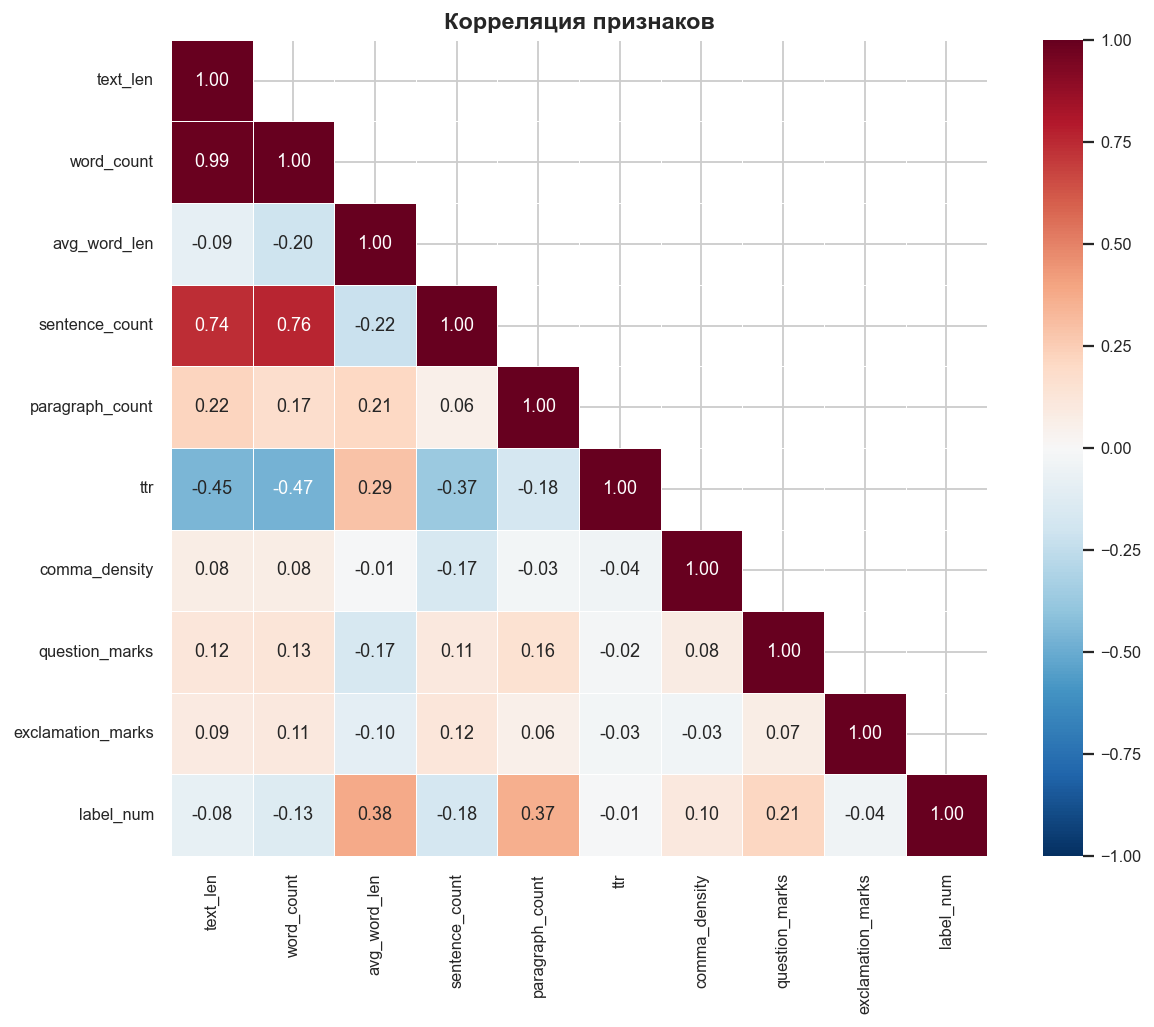

In [28]:
df["label_num"] = (df["label"] == "ai").astype(int)

feat_cols = ["text_len", "word_count", "avg_word_len", "sentence_count",
             "paragraph_count", "ttr", "comma_density",
             "question_marks", "exclamation_marks", "label_num"]

corr = df[feat_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, square=True, lw=.5, ax=ax, vmin=-1, vmax=1)
ax.set_title("Корреляция признаков")
plt.tight_layout()
plt.show()

In [29]:
label_corr = corr["label_num"].drop("label_num").sort_values(key=abs, ascending=False)
print("Корреляция с меткой (ai=1):")
label_corr.to_frame("r").round(3)

Корреляция с меткой (ai=1):


,r
avg_word_len,0.382
paragraph_count,0.366
question_marks,0.214
sentence_count,-0.177
word_count,-0.134
comma_density,0.104
text_len,-0.083
exclamation_marks,-0.045
ttr,-0.012


Топ-3 по корреляции с меткой: `avg_word_len` (0.38), `paragraph_count` (0.37), `question_marks` (0.21). Но `paragraph_count` - артефакт форматирования, не содержания.

`text_len` и `word_count` коррелируют >0.9 между собой - хватит одного. `ttr` почти не коррелирует с меткой (-0.01) - без нормализации по длине он бесполезен.

note: после strip_markdown корреляция `paragraph_count` должна упасть - нужно проверить.

## Рекомендации по признакам

In [30]:
recs = [
    ("char_len",         "слабый",  "нет",      "коррелирует с word_count, избыточна"),
    ("word_count",       "слабый",  "нет",      "оставить как базовый, не ключевой"),
    ("sent_count",       "слабый",  "нет",      "коррелирует с длиной"),
    ("avg_word_len",     "средний", "нет",      "AI использует длинные слова - полезный"),
    ("avg_sent_len",     "средний", "нет",      "устойчивый сигнал"),
    ("type_token_ratio", "сильный", "нет",      "нормализовать по длине (MATTR)"),
    ("punct_ratio",      "слабый",  "частично", "после очистки markdown - слабый"),
    ("question_marks",   "средний", "нет",      "prompt-артефакт, но информативен"),
    ("n_paragraphs",     "сильный", "ДА",       "shortcut - нормализовать \\n\\n"),
    ("has_markdown",     "сильный", "ДА",       "убрать ДО обучения"),
    ("ends_formulaic",   "средний", "нет",      "устойчивый, не зависит от форматирования"),
    ("log_odds_words",   "сильный", "нет",      "LLM-маркеры (является, контекст, аспект)"),
]

rec_df = pd.DataFrame(recs, columns=["фича", "сигнал", "markdown?", "комментарий"])

def _hl(v):
    return "background-color: #ffcccc" if v == "ДА" else ""

rec_df.style.map(_hl, subset=["markdown?"])

,фича,сигнал,markdown?,комментарий
0,char_len,слабый,нет,"коррелирует с word_count, избыточна"
1,word_count,слабый,нет,"оставить как базовый, не ключевой"
2,sent_count,слабый,нет,коррелирует с длиной
3,avg_word_len,средний,нет,AI использует длинные слова - полезный
4,avg_sent_len,средний,нет,устойчивый сигнал
5,type_token_ratio,сильный,нет,нормализовать по длине (MATTR)
6,punct_ratio,слабый,частично,после очистки markdown - слабый
7,question_marks,средний,нет,"prompt-артефакт, но информативен"
8,n_paragraphs,сильный,ДА,shortcut - нормализовать \n\n
9,has_markdown,сильный,ДА,убрать ДО обучения


## Adversarial-тексты

Adversarial-выборка не участвует в основном EDA (только для test), 
приводим базовую статистику.

In [31]:
# adversarial: краткая статистика
if len(df_adv) > 0:
    print(f"Adversarial текстов: {len(df_adv)}")
    src_counts = df_adv["source_name"].value_counts().to_dict()
    dom_counts = df_adv["domain"].value_counts().to_dict()
    print(f"Источники: {src_counts}")
    print(f"Домены: {dom_counts}")
    lens = df_adv["text"].str.len()
    print(f"Длина: min={lens.min()}, median={lens.median():.0f}, max={lens.max()}")


Adversarial текстов: 516
Источники: {'GigaChat': 508, 'yandexgpt-lite': 8}
Домены: {'news': 243, 'essay': 141, 'wiki': 132}
Длина: min=242, median=2010, max=4789


## Форматные различия human vs AI

Помимо markdown (который мы убрали strip_markdown), есть форматные паттерны которые остаются после очистки. Проверим, нет ли тут шорткатов.

In [32]:
# форматные маркеры: сравнение human vs AI
format_metrics = {
    "em-dash": lambda t: t.count("\u2014"),
    "guillemets": lambda t: len(re.findall("[\u00ab\u00bb]", t)),
    "parens": lambda t: len(re.findall("[()]", t)),
    "colon": lambda t: t.count(":"),
    "digits": lambda t: len(re.findall(r"\d+", t)),
    "pct": lambda t: t.count("%"),
    "backslash": lambda t: t.count("\\"),
    "slash": lambda t: t.count("/"),
}

rows = []
for metric_name, fn in format_metrics.items():
    h_vals = df[df["label"] == "human"]["text"].apply(fn)
    a_vals = df[df["label"] == "ai"]["text"].apply(fn)
    ratio = h_vals.mean() / a_vals.mean() if a_vals.mean() > 0 else float('inf')
    rows.append({
        "metric": metric_name,
        "human_mean": round(h_vals.mean(), 2),
        "ai_mean": round(a_vals.mean(), 2),
        "ratio": f"{ratio:.1f}x",
    })

fmt_df = pd.DataFrame(rows)
print(fmt_df.to_string(index=False))

    metric  human_mean  ai_mean ratio
   em-dash        6.88     1.84  3.7x
guillemets       10.18     1.84  5.5x
    parens       11.33     3.16  3.6x
     colon        2.77     2.27  1.2x
    digits       24.75     2.85  8.7x
       pct        0.42     0.18  2.3x
 backslash        0.39     0.58  0.7x
     slash        1.43     0.06 24.2x


Human-тексты (Habr, Wiki, Taiga) содержат цифры, скобки, тире и кавычки-ёлочки в 6-24 раза чаще чем AI. Это форматный шорткат - не тематический (тема та же), а стилистический (источники исторически используют такое форматирование, AI - нет).

Не чистим, но учитываем: эти признаки войдут в стилометрию, и мы будем знать какую долю качества модели объясняет форматирование.

note: при расширении human-корпуса в будущем нужно следить за балансом форматных паттернов.

## Итоги

In [33]:
n_h = len(df[df["label"] == "human"])
n_a = len(df[df["label"] == "ai"])
med_h = df.loc[df["label"] == "human", "text_len"].median()
med_a = df.loc[df["label"] == "ai", "text_len"].median()
ttr_h = df.loc[df["label"] == "human", "ttr"].mean()
ttr_a = df.loc[df["label"] == "ai", "ttr"].mean()

print(f"Human: {n_h:,}, AI: {n_a:,}")
print(f"Медиана длины - human: {med_h:.0f}, AI: {med_a:.0f}")
print(f"TTR (ср.) - human: {ttr_h:.3f}, AI: {ttr_a:.3f}")
print()
print("Топ-3 признака по |корреляции| с label:")
for feat, val in label_corr.head(3).items():
    print(f"  {feat}: {val:.3f}")

Human: 15,530, AI: 23,650
Медиана длины - human: 2538, AI: 2823
TTR (ср.) - human: 0.688, AI: 0.685

Топ-3 признака по |корреляции| с label:
  avg_word_len: 0.382
  paragraph_count: 0.366
  question_marks: 0.214


Корпус: 15 530 human / 23 650 AI (39.6% / 60.4%). Нужна балансировка при сборке сплитов.

Главные shortcut-ы: markdown (до 90% AI vs 0% human), двойные переносы (median 7 vs 0), шаблонные фразы (17% vs 1.5%). Markdown нужно убрать до обучения.

Устойчивые стилистические признаки: `avg_word_len` (AI 7.94, human 7.52, d > 0.5), `question_marks` (AI 0.88, human 0.20), LLM-маркеры из log-odds (`является`, `контекст`, `аспект`).

TTR без нормализации бесполезен. Домены сильно отличаются - нужно учитывать при обучении. Для unseen-модели в holdout можно вынести yandexgpt.

note: после очистки markdown пересчитать корреляции и проверить, какие признаки останутся сильными.